In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Tải dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 2. Tiền xử lý
# Loại bỏ cột không cần thiết
df = df.drop('customer_id', axis=1)

# Mã hóa biến phân loại
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df = pd.get_dummies(df, columns=['country'], drop_first=True)

# Chia X, y
X = df.drop('churn', axis=1)
y = df['churn']

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Định nghĩa các mô hình
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 4. Huấn luyện và Đánh giá
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    })

# Hiển thị kết quả so sánh
results_df = pd.DataFrame(results).drop('Confusion Matrix', axis=1)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression    0.8110   0.552448  0.201018  0.294776
1        Decision Tree    0.8575   0.764706  0.396947  0.522613
2        Random Forest    0.8665   0.764706  0.463104  0.576862


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 2. Tiền xử lý
# Loại bỏ customer_id
df = df.drop('customer_id', axis=1)

# Mã hóa dữ liệu dạng phân loại (Country, Gender)
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df = pd.get_dummies(df, columns=['country'], drop_first=True) # One-hot encoding cho Country

# 3. Chia dữ liệu Train/Test (80/20)
X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa dữ liệu (Scaling) - Cực kỳ quan trọng cho Logistic Regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

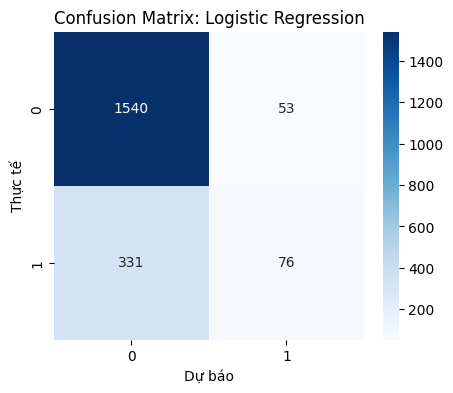

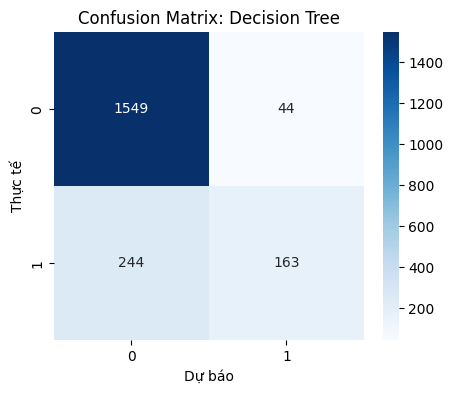

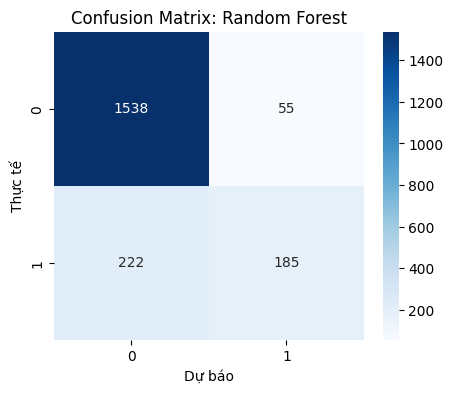

                 Model  Accuracy  Precision    Recall  F1-score
2        Random Forest    0.8615   0.770833  0.454545  0.571870
1        Decision Tree    0.8560   0.787440  0.400491  0.530945
0  Logistic Regression    0.8080   0.589147  0.186732  0.283582


In [ ]:
# Khởi tạo các mô hình
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# Huấn luyện và lấy chỉ số
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    # In Confusion Matrix cho từng mô hình
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự báo')
    plt.show()

# Hiển thị bảng so sánh
df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
print(df_results.sort_values(by='F1-score', ascending=False))